In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv(r'E:/ecommerce_project/data/ecommerece_raw.csv',encoding='latin1')

# First look
print(df.shape)
print(df.head())
print(df.info())
print(df.isnull().sum())

(541909, 8)
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

        InvoiceDate  UnitPrice  CustomerID         Country  
0  12-01-2010 08:26       2.55     17850.0  United Kingdom  
1  12-01-2010 08:26       3.39     17850.0  United Kingdom  
2  12-01-2010 08:26       2.75     17850.0  United Kingdom  
3  12-01-2010 08:26       3.39     17850.0  United Kingdom  
4  12-01-2010 08:26       3.39     17850.0  United Kingdom  
<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0  

In [3]:
# Drop rows with missing CustomerID (can't analyze without it)
df = df.dropna(subset=['CustomerID'])

# Remove cancelled orders (InvoiceNo starting with 'C')
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

# Remove rows with negative or zero Quantity/UnitPrice
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

# Fix data types
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], format='%m/%d/%Y %H:%M')
df['CustomerID'] = df['CustomerID'].astype(int)

# Create Revenue column
df['Revenue'] = df['Quantity'] * df['UnitPrice']

# Extract Month & Year for time analysis
df['Month'] = df['InvoiceDate'].dt.to_period('M')

print("Clean data shape:", df.shape)
print(df.head())

ValueError: time data "12-01-2010 08:26" doesn't match format "%m/%d/%Y %H:%M". You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [5]:
# Drop rows with missing CustomerID (can't analyze without it)
df = df.dropna(subset=['CustomerID'])

# Remove cancelled orders (InvoiceNo starting with 'C')
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

# Remove rows with negative or zero Quantity/UnitPrice
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

# Fix data types
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], format='mixed', errors='coerce')
df['CustomerID'] = df['CustomerID'].astype(int)

# Create Revenue column
df['Revenue'] = df['Quantity'] * df['UnitPrice']

# Extract Month & Year for time analysis
df['Month'] = df['InvoiceDate'].dt.to_period('M')

print("Clean data shape:", df.shape)
print(df.head())

Clean data shape: (397884, 10)
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  Revenue    Month  
0 2010-12-01 08:26:00       2.55       17850  United Kingdom    15.30  2010-12  
1 2010-12-01 08:26:00       3.39       17850  United Kingdom    20.34  2010-12  
2 2010-12-01 08:26:00       2.75       17850  United Kingdom    22.00  2010-12  
3 2010-12-01 08:26:00       3.39       17850  United Kingdom    20.34  2010-12  
4 2010-12-01 08:26:00       3.39       17850  United Kingdom    20.34  2010-12  


C:\Users\Admin\AppData\Local\Temp\ipykernel_13460\1167758893.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products.values, y=top_products.index, palette='viridis')


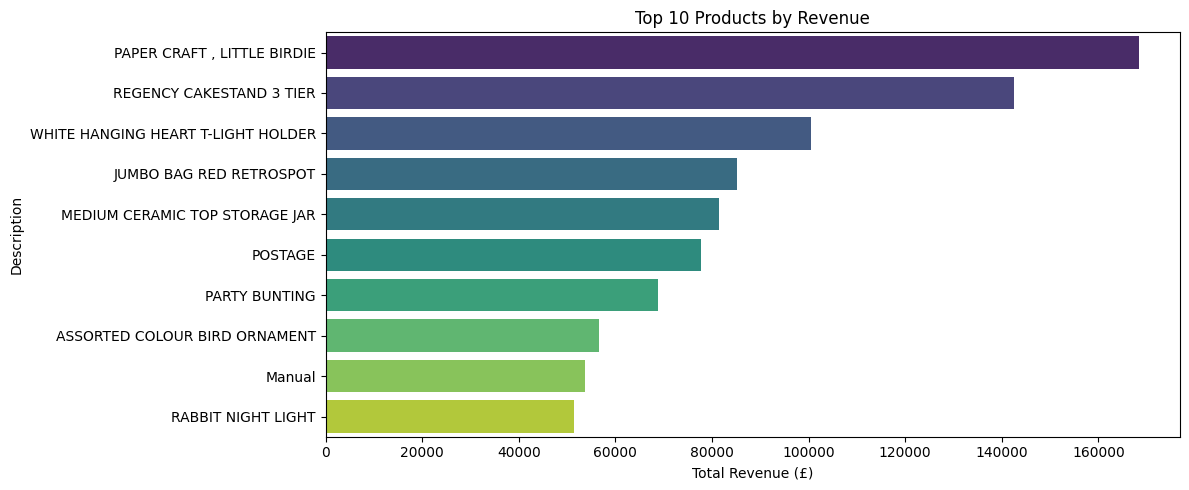

In [6]:
top_products = df.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 5))
sns.barplot(x=top_products.values, y=top_products.index, palette='viridis')
plt.title('Top 10 Products by Revenue')
plt.xlabel('Total Revenue (£)')
plt.tight_layout()
plt.savefig('../outputs/top_products.png')
plt.show()

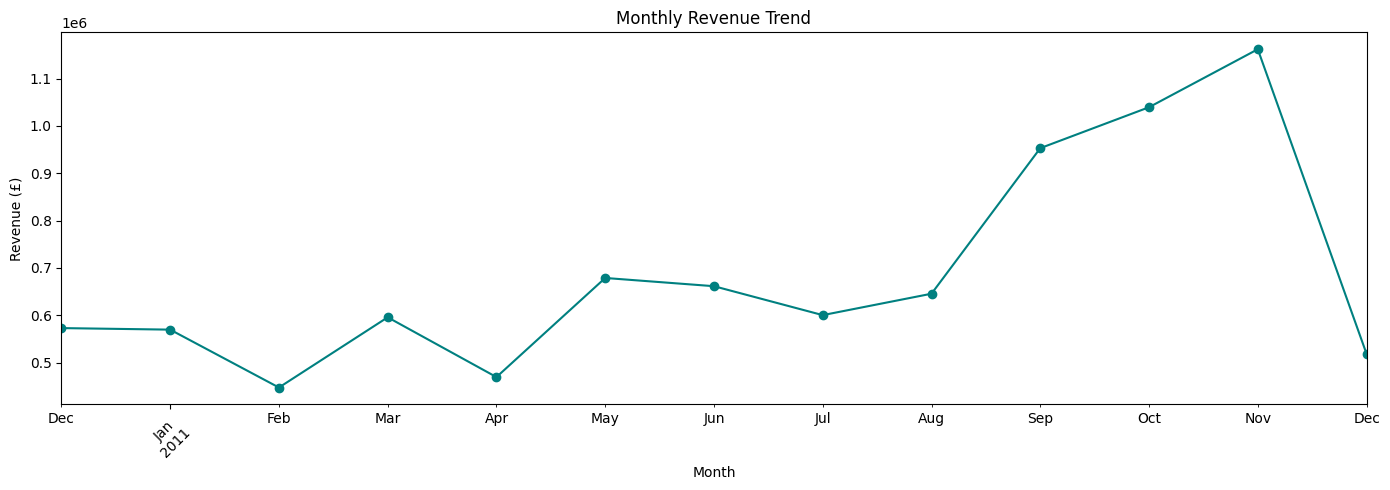

In [7]:
monthly_revenue = df.groupby('Month')['Revenue'].sum()

plt.figure(figsize=(14, 5))
monthly_revenue.plot(kind='line', marker='o', color='teal')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue (£)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../outputs/monthly_revenue.png')
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_13460\1886690619.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette='magma')


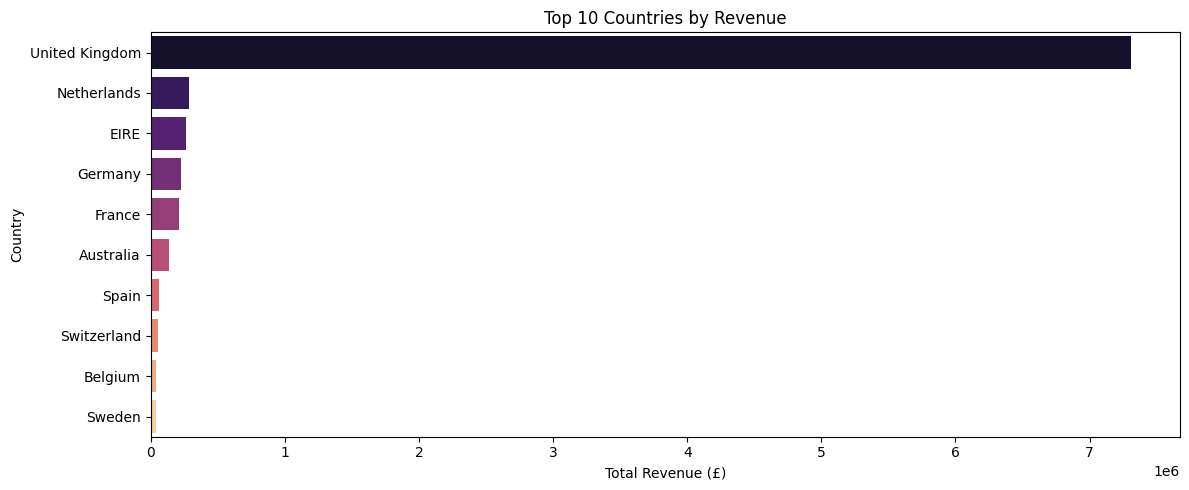

In [8]:
top_countries = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 5))
sns.barplot(x=top_countries.values, y=top_countries.index, palette='magma')
plt.title('Top 10 Countries by Revenue')
plt.xlabel('Total Revenue (£)')
plt.tight_layout()
plt.savefig('../outputs/top_countries.png')
plt.show()

In [2]:
df.to_csv('E:/ecommerce_project/data/ecommerce_clean.csv', index=False)
print("✅ Cleaned data saved!")

✅ Cleaned data saved!


In [ ]:
import pandas as pd
import mysql.connector
import numpy as np

# Connect to MySQL
conn = mysql.connector.connect(
    host='localhost',
    user='root',
    password='root123',  # replace with your MySQL password
    database='ecommerce_db'
)
cursor = conn.cursor()

# Load RAW CSV (not cleaned)
df = pd.read_csv('E:/ecommerce_project/data/ecommerece_raw.csv', encoding='latin-1')

print("Original columns:", df.columns.tolist())
print("Original shape:", df.shape)

# ✅ Step 1 — Drop missing CustomerID
df = df.dropna(subset=['CustomerID'])

# ✅ Step 2 — Remove cancelled orders
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

# ✅ Step 3 — Remove negative/zero values
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

# ✅ Step 4 — Fix data types
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], format='mixed')
df['CustomerID'] = df['CustomerID'].astype(int)

# ✅ Step 5 — Create Revenue and Month columns
df['Revenue'] = df['Quantity'] * df['UnitPrice']
df['Month'] = df['InvoiceDate'].dt.to_period('M').astype(str)

# ✅ Step 6 — Keep only required columns
df = df[['InvoiceNo', 'StockCode', 'Description', 'Quantity',
         'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country',
         'Revenue', 'Month']]

# ✅ Step 7 — Replace NaN with None
df = df.astype(object).where(pd.notnull(df), None)

print("Clean columns:", df.columns.tolist())
print("Clean shape:", df.shape)
print("Sample:\n", df.head(2))

# ✅ Step 8 — Drop and recreate table
cursor.execute("DROP TABLE IF EXISTS sales")
cursor.execute("""
    CREATE TABLE sales (
        InvoiceNo VARCHAR(20),
        StockCode VARCHAR(20),
        Description VARCHAR(255),
        Quantity INT,
        InvoiceDate DATETIME,
        UnitPrice DECIMAL(10,2),
        CustomerID INT,
        Country VARCHAR(100),
        Revenue DECIMAL(10,2),
        Month VARCHAR(20)
    )
""")
conn.commit()
print("✅ Table recreated!")

# ✅ Step 9 — Insert in chunks
insert_query = """
    INSERT INTO sales 
    (InvoiceNo, StockCode, Description, Quantity, InvoiceDate,
     UnitPrice, CustomerID, Country, Revenue, Month)
    VALUES (%s, %s, %s, %s, %s, %s, %s, %s, %s, %s)
"""

data = [tuple(row) for row in df.itertuples(index=False, name=None)]

chunk_size = 1000
for i in range(0, len(data), chunk_size):
    cursor.executemany(insert_query, data[i:i+chunk_size])
    conn.commit()
    print(f"✅ Inserted rows {i} to {i+chunk_size}")

print("🎉 All data inserted successfully!")
cursor.close()
conn.close()

Original columns: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']
Original shape: (541909, 8)
Clean columns: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country', 'Revenue', 'Month']
Clean shape: (397884, 10)
Sample:
   InvoiceNo StockCode                         Description Quantity  \
0    536365    85123A  WHITE HANGING HEART T-LIGHT HOLDER        6   
1    536365     71053                 WHITE METAL LANTERN        6   

           InvoiceDate UnitPrice CustomerID         Country Revenue    Month  
0  2010-12-01 08:26:00      2.55      17850  United Kingdom    15.3  2010-12  
1  2010-12-01 08:26:00      3.39      17850  United Kingdom   20.34  2010-12  


In [ ]:
import pandas as pd
import mysql.connector

conn = mysql.connector.connect(
    host='localhost',
    user='root',
    password='root123',
    database='ecommerce_db',
    connection_timeout=300
)

# ✅ Query 1 — Top 10 Products by Revenue
q1 = """
    SELECT Description,
           ROUND(SUM(Revenue), 2) AS total_revenue,
           SUM(Quantity)          AS total_units_sold
    FROM sales
    GROUP BY Description
    ORDER BY total_revenue DESC
    LIMIT 10
"""
df_products = pd.read_sql(q1, conn)
print(df_products)
df_products.to_csv('E:/ecommerce_project/excel/top_products.csv', index=False)
print("✅ top_products.csv saved!")

# ✅ Query 2 — Monthly Revenue Growth
q2 = """
    WITH monthly AS (
        SELECT Month,
               ROUND(SUM(Revenue), 2) AS total_revenue
        FROM sales
        GROUP BY Month
    ),
    growth AS (
        SELECT Month,
               total_revenue,
               LAG(total_revenue) OVER (ORDER BY Month) AS prev_month_revenue
        FROM monthly
    )
    SELECT Month,
           total_revenue,
           prev_month_revenue,
           ROUND(((total_revenue - prev_month_revenue) 
                  / prev_month_revenue) * 100, 2) AS mom_growth_pct
    FROM growth
"""
df_growth = pd.read_sql(q2, conn)
print(df_growth)
df_growth.to_csv('E:/ecommerce_project/excel/monthly_growth.csv', index=False)
print("✅ monthly_growth.csv saved!")

# ✅ Query 3 — Customer Segmentation
q3 = """
    WITH rfm AS (
        SELECT CustomerID,
               DATEDIFF('2011-12-31', MAX(InvoiceDate)) AS recency,
               COUNT(DISTINCT InvoiceNo)                AS frequency,
               ROUND(SUM(Revenue), 2)                   AS monetary
        FROM sales
        GROUP BY CustomerID
    )
    SELECT *,
        CASE
            WHEN recency <= 30 AND frequency >= 10 AND monetary >= 1000 THEN 'Champion'
            WHEN recency <= 60 AND frequency >= 5  AND monetary >= 500  THEN 'Loyal'
            WHEN recency <= 90 AND frequency >= 2                       THEN 'Potential'
            ELSE 'At Risk'
        END AS customer_segment
    FROM rfm
    ORDER BY monetary DESC
"""
df_segments = pd.read_sql(q3, conn)
print(df_segments)
df_segments.to_csv('E:/ecommerce_project/excel/customer_segments.csv', index=False)
print("✅ customer_segments.csv saved!")

# ✅ Query 4 — Country wise Sales
q4 = """
    SELECT Country,
           COUNT(DISTINCT InvoiceNo)  AS total_orders,
           COUNT(DISTINCT CustomerID) AS total_customers,
           ROUND(SUM(Revenue), 2)     AS total_revenue,
           ROUND(AVG(Revenue), 2)     AS avg_order_value
    FROM sales
    GROUP BY Country
    ORDER BY total_revenue DESC
    LIMIT 15
"""
df_countries = pd.read_sql(q4, conn)
print(df_countries)
df_countries.to_csv('E:/ecommerce_project/excel/country_sales.csv', index=False)
print("✅ country_sales.csv saved!")

# ✅ Query 5 — Best Selling Products by Quantity
q5 = """
    SELECT StockCode,
           Description,
           SUM(Quantity)           AS total_units_sold,
           ROUND(SUM(Revenue), 2)  AS total_revenue,
           ROUND(AVG(UnitPrice),2) AS avg_price
    FROM sales
    GROUP BY StockCode, Description
    ORDER BY total_units_sold DESC
    LIMIT 10
"""
df_best = pd.read_sql(q5, conn)
print(df_best)
df_best.to_csv('E:/ecommerce_project/excel/best_selling.csv', index=False)
print("✅ best_selling.csv saved!")

conn.close()
print("\n🎉 All queries done and CSVs saved to excel folder!")